In this part of the project, a Convolutional Neural Network is used to classify natural scene images.  
The dataset used is the Intel Image Classification dataset, which contains six classes: buildings, forest, glacier, mountain, sea, and street.

The objective is to train a CNN model that can recognize the scene category of an input image.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import os
import zipfile

from google.colab import drive

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from keras.models import Sequential
from keras.layers import Dense, Flatten, Conv2D, MaxPooling2D, Dropout

drive.mount('/content/drive')

zip_path = '/content/drive/MyDrive/Computer Vision Project/ClassificationDataset.zip'
extract_path = '/content/IntelDataset'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print(os.listdir(extract_path))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
['seg_train', 'seg_test', 'seg_pred']


Before training the CNN, some sample images are visualized in order to understand the different scene categories contained in the dataset.

Classes:
['sea', 'street', 'buildings', 'glacier', 'mountain', 'forest']


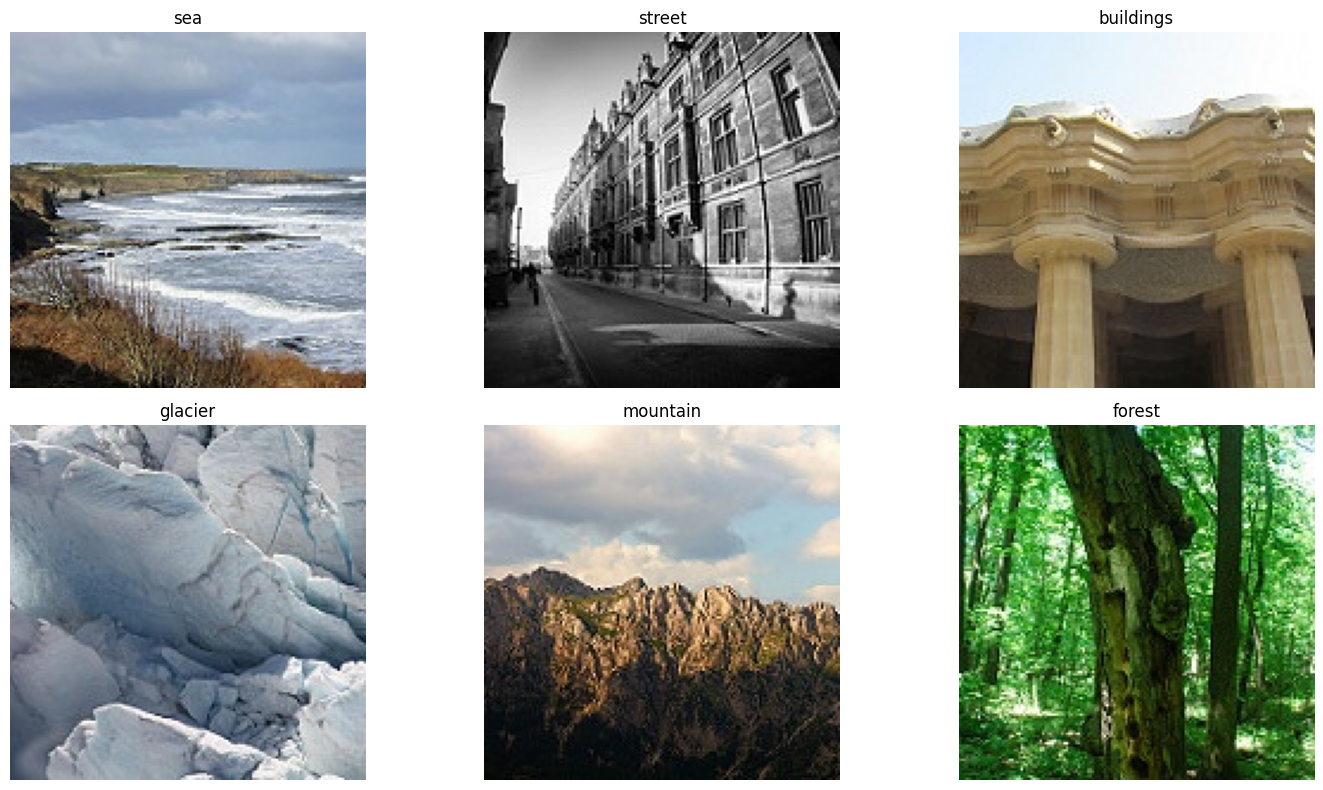

In [ ]:
train_path = '/content/IntelDataset/seg_train/seg_train'

classes = os.listdir(train_path)

print('Classes:')
print(classes)

import matplotlib.image as mpimg

plt.figure(figsize=(15,8))

for i, c in enumerate(classes):

    img_name = os.listdir(os.path.join(train_path,c))[0]

    img_path = os.path.join(train_path,c,img_name)

    img = mpimg.imread(img_path)

    plt.subplot(2,3,i+1)
    plt.imshow(img)
    plt.title(c)
    plt.axis('off')

plt.tight_layout()
plt.show()

The images are loaded from the class folders using ImageDataGenerator. The pixel values are rescaled from 0-255 to 0-1 and part of the training data is used as validation data.

In [ ]:
train_path = '/content/IntelDataset/seg_train/seg_train'
test_path = '/content/IntelDataset/seg_test/seg_test'

IMG_SIZE = 150
BATCH_SIZE = 64

In [ ]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    horizontal_flip=True,
    zoom_range=0.2
)

test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training'
)

val_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation'
)

test_generator = test_datagen.flow_from_directory(
    test_path,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

Found 11230 images belonging to 6 classes.
Found 2804 images belonging to 6 classes.
Found 3000 images belonging to 6 classes.


In [ ]:
print(train_generator.class_indices)

{'buildings': 0, 'forest': 1, 'glacier': 2, 'mountain': 3, 'sea': 4, 'street': 5}


A CNN model is built using convolution and pooling layers for feature extraction, followed by dense layers for classification. Dropout was also added to reduce overfitting.




In [ ]:
model = Sequential()

model.add(Conv2D(32, (3, 3), activation='relu', input_shape=(IMG_SIZE,IMG_SIZE,3)))
model.add(MaxPooling2D(pool_size=(2, 2)))

model.add(Conv2D(64, (3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))

model.add(Conv2D(128, (3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))

model.add(Flatten())

model.add(Dense(512, activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(6, activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(loss='categorical_crossentropy',
              optimizer='adam',
              metrics=['accuracy'])

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │    18,940,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │         3,078 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,036,742 (72.62 MB)

 Trainable params: 19,036,742 (72.62 MB)

 Non-trainable params: 0 (0.00 B)

The model is now trained using the training set while monitoring the validation set performance after each epoch.

In [ ]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=15
)

Epoch 1/15
176/176 ━━━━━━━━━━━━━━━━━━━━ 98s 515ms/step - accuracy: 0.5435 - loss: 1.1847 - val_accuracy: 0.6159 - val_loss: 0.9494
Epoch 2/15
176/176 ━━━━━━━━━━━━━━━━━━━━ 82s 469ms/step - accuracy: 0.6879 - loss: 0.8323 - val_accuracy: 0.7282 - val_loss: 0.7292
Epoch 3/15
176/176 ━━━━━━━━━━━━━━━━━━━━ 81s 461ms/step - accuracy: 0.7411 - loss: 0.7088 - val_accuracy: 0.7564 - val_loss: 0.6738
Epoch 4/15
176/176 ━━━━━━━━━━━━━━━━━━━━ 82s 467ms/step - accuracy: 0.7809 - loss: 0.6154 - val_accuracy: 0.7921 - val_loss: 0.5871
Epoch 5/15
176/176 ━━━━━━━━━━━━━━━━━━━━ 83s 470ms/step - accuracy: 0.7998 - loss: 0.5683 - val_accuracy: 0.8149 - val_loss: 0.5181
Epoch 6/15
176/176 ━━━━━━━━━━━━━━━━━━━━ 83s 471ms/step - accuracy: 0.8192 - loss: 0.5069 - val_accuracy: 0.8338 - val_loss: 0.4796
Epoch 7/15
176/176 ━━━━━━━━━━━━━━━━━━━━ 82s 466ms/step - accuracy: 0.8277 - loss: 0.4877 - val_accuracy: 0.8352 - val_loss: 0.4837
Epoch 8/15
176/176 ━━━━━━━━━━━━━━━━━━━━ 81s 461ms/step - accuracy: 0.8399 - loss: 0

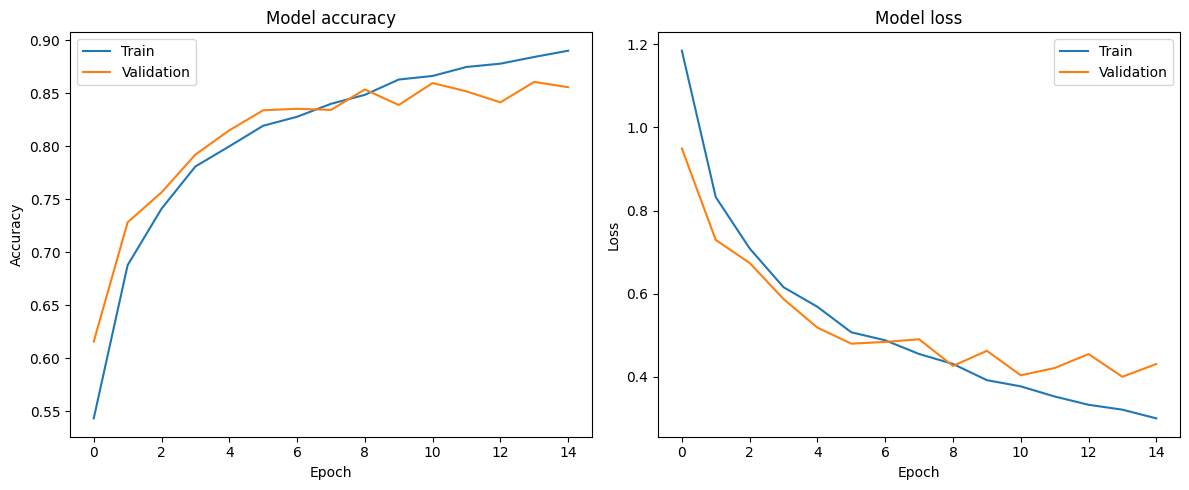

In [ ]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train','Validation'])

plt.subplot(1,2,2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train','Validation'])

plt.tight_layout()
plt.show()

In [ ]:
score = model.evaluate(test_generator)

print('Test loss = {}'.format(score[0]))
print('Test accuracy = {}'.format(score[1]))

47/47 ━━━━━━━━━━━━━━━━━━━━ 4s 80ms/step - accuracy: 0.8537 - loss: 0.4730
Test loss = 0.4730047285556793
Test accuracy = 0.8536666631698608


The CNN achieved a final training accuracy of approximately 90%, while the validation and test accuracies were around 85%. The close agreement between validation and test performance indicates that the model generalizes well to unseen images. A slight degree of overfitting can be observed after approximately 10 epochs, where the training accuracy continues to increase while the validation accuracy stabilizes.

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

47/47 ━━━━━━━━━━━━━━━━━━━━ 8s 151ms/step


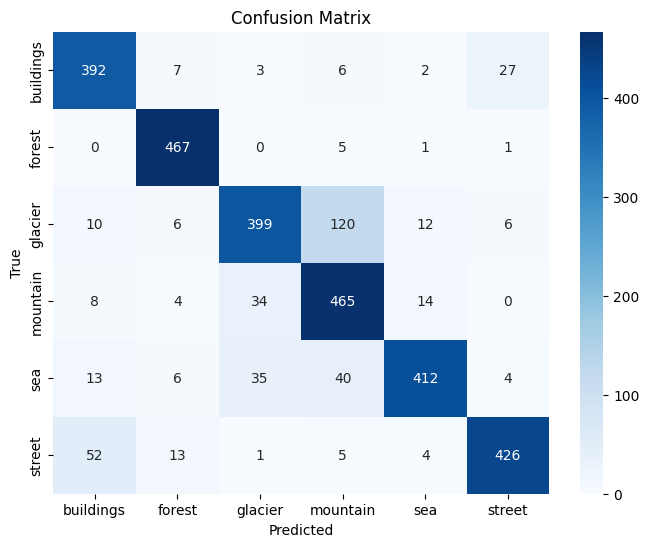

In [ ]:
y_pred = model.predict(test_generator)

y_pred_classes = np.argmax(y_pred, axis=1)

cm = confusion_matrix(test_generator.classes,
                      y_pred_classes)

plt.figure(figsize=(8,6))

sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=list(train_generator.class_indices.keys()),
            yticklabels=list(train_generator.class_indices.keys()))

plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')

plt.show()

Most classes are classified well. The strongest confusion is between glacier and mountain, which is expected because both contain similar rocky/icy landscape structures. Some streets are also confused with buildings because both contain urban elements.

In [ ]:
from sklearn.metrics import classification_report

class_names = list(test_generator.class_indices.keys())

print(classification_report(test_generator.classes,
                            y_pred_classes,
                            target_names=class_names))

              precision    recall  f1-score   support

   buildings       0.83      0.90      0.86       437
      forest       0.93      0.99      0.96       474
     glacier       0.85      0.72      0.78       553
    mountain       0.73      0.89      0.80       525
         sea       0.93      0.81      0.86       510
      street       0.92      0.85      0.88       501

    accuracy                           0.85      3000
   macro avg       0.86      0.86      0.86      3000
weighted avg       0.86      0.85      0.85      3000



The model achieved an overall test accuracy of approximately 85%. The best performing class was forest, with precision and recall values close to 0.93 and 0.99 respectively, indicating that forest scenes are easily distinguishable from the other categories. The most challenging classes were glacier and mountain, which is consistent with the confusion matrix since both classes contain similar landscape characteristics. Buildings and street images also showed some confusion due to the presence of common urban structures. Overall, the model demonstrates good generalization across all six scene categories.

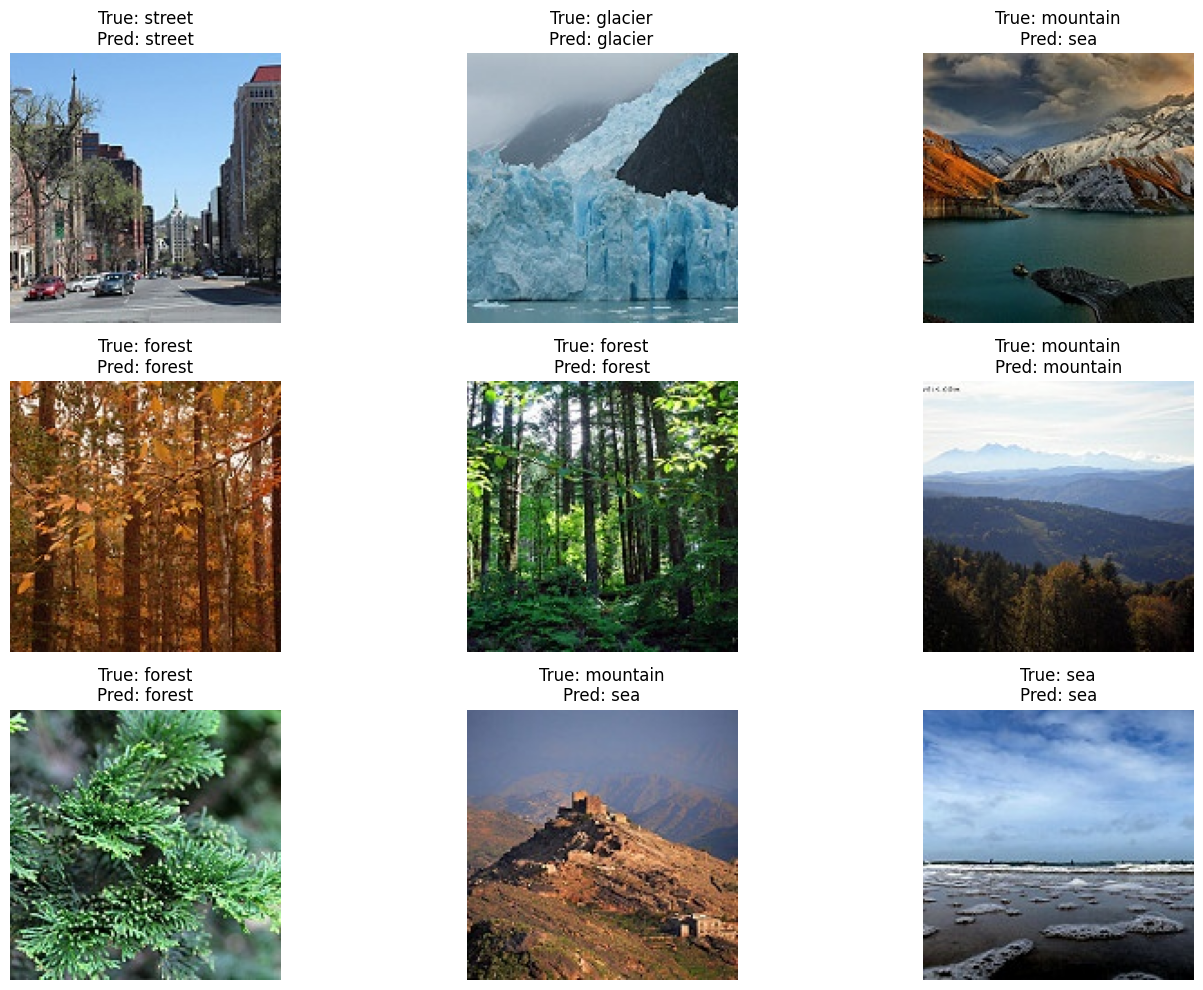

In [ ]:
import random
from tensorflow.keras.preprocessing import image

class_names = list(test_generator.class_indices.keys())

plt.figure(figsize=(15,10))

for i in range(0,9):

    rand_class = random.choice(class_names)

    rand_file = random.choice(
        os.listdir(os.path.join(test_path, rand_class))
    )

    img_path = os.path.join(test_path,
                            rand_class,
                            rand_file)

    img = image.load_img(img_path,
                         target_size=(IMG_SIZE, IMG_SIZE))

    img_array = image.img_to_array(img)

    img_array = img_array / 255.0

    img_input = np.expand_dims(img_array, axis=0)

    prediction = model.predict(img_input, verbose=0)

    predicted_class = class_names[np.argmax(prediction)]

    plt.subplot(3,3,i+1)
    plt.imshow(img_array)
    plt.title('True: {}\nPred: {}'.format(rand_class,
                                          predicted_class))
    plt.axis('off')

plt.tight_layout()
plt.show()

Several randomly selected test images are shown here which were classified using the trained CNN. Most scene categories were correctly identified, particularly forest, sea and mountain images, which contain distinctive visual characteristics. Some misclassifications can be observed, especially between mountain and sea scenes, since these categories often share similar colors, textures and landscape structures. Overall, the examples confirm the results obtained from the confusion matrix and demonstrate that the model is capable of generalizing well to previously unseen images.